## 6. Probability Density Functions

- ### additional resources
- https://www.youtube.com/watch?v=hDjcxi9p0ak
- https://www.youtube.com/watch?v=YXLVjCKVP7U

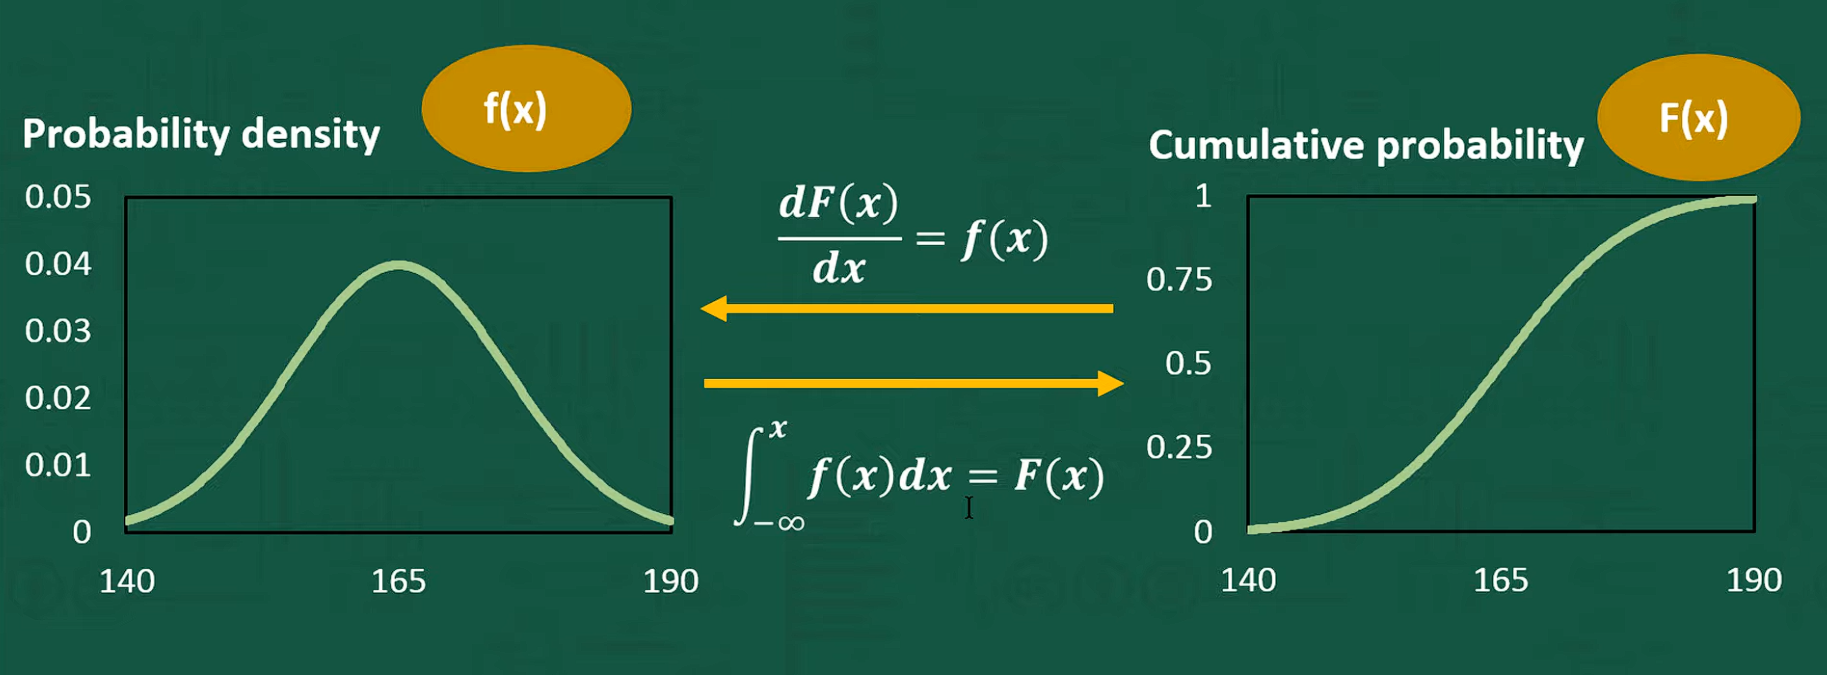

^ Y- axis on PDF represents gradient of CDF, you can see on the PDF that the gradient is maximized at 165.

- The binomial and Poisson distributions are discrete, which means that the outcomes have to be distinct or separate elements, like an integer number of hits and misses, or goals scored. In a discrete distribution, each outcome is associated with a probability mass.

- The exponential and normal distribution are continuous, which means the outcomes can be at any point in a range of possible values. In a continuous distribution, each outcome is associated with a probability density.

In [15]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../nb')

try:
    import statadict
except ImportError:
    %pip install statadict

In [3]:
os.chdir('../data')

from nsfg import read_fem_resp

resp = read_fem_resp()

os.chdir('../my-work')
resp.head()


C:\Users\xannx\PycharmProjects\ThinkStats\data\../nb\nsfg.py:191: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resp["agemarry"] = (resp.cmmarrhx - resp.cmbirth) / 12.0
C:\Users\xannx\PycharmProjects\ThinkStats\data\../nb\nsfg.py:192: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resp["age"] = (resp.cmintvw - resp.cmbirth) / 12.0
C:\Users\xannx\PycharmProjects\ThinkStats\data\../nb\nsfg.py:195: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor per

,caseid,rscrinf,rdormres,rostscrn,rscreenhisp,rscreenrace,age_a,age_r,cmbirth,agescrn,...,sest,cmintvw,cmlstyr,screentime,intvlngth,agemarry,age,year,decade,fives
0,2298,1,5,5,1,5.0,27,27,902,27,...,18,1234,1222,18:26:36,110.492667,NaN,27.666667,75,7,15
1,5012,1,5,1,5,5.0,42,42,718,42,...,18,1233,1221,16:30:59,64.294000,21.333333,42.916667,59,5,11
2,11586,1,5,1,5,5.0,43,43,708,43,...,18,1234,1222,18:19:09,75.149167,16.833333,43.833333,58,5,11
3,6794,5,5,4,1,5.0,15,15,1042,15,...,18,1234,1222,15:54:43,28.642833,NaN,16.000000,86,8,17
4,616,1,5,4,1,5.0,20,20,991,20,...,18,1233,1221,14:19:44,69.502667,NaN,20.166667,82,8,16


In [4]:
older = resp.query("age >= 25")
num_family = older["numfmhh"]

In [5]:
from empiricaldist import Pmf

pmf_family = Pmf.from_seq(num_family, name="data")

In [6]:
from thinkstats import poisson_pmf

lam = 2.2
ks = np.arange(11)
ps = poisson_pmf(ks, lam)

pmf_poisson = Pmf(ps, ks, name="Poisson model")

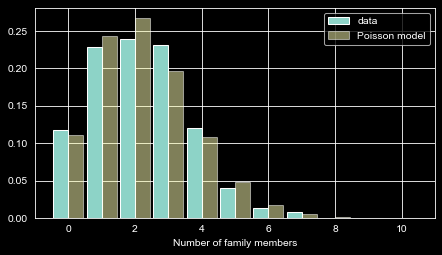

In [7]:
from thinkstats import two_bar_plots, decorate

two_bar_plots(pmf_family, pmf_poisson)
decorate(xlabel="Number of family members")

In [8]:
cdf_family = pmf_family.make_cdf()
cdf_poisson = pmf_poisson.make_cdf()

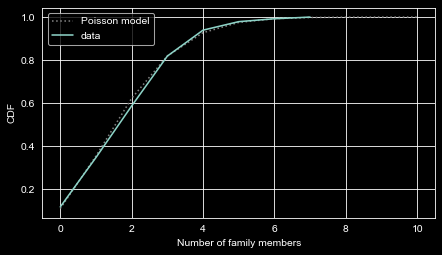

In [9]:
from thinkstats import two_cdf_plots

two_cdf_plots(cdf_poisson, cdf_family)
decorate(xlabel="Number of family members")

In [10]:
os.chdir('../data')

from nsfg import read_fem_preg

preg = read_fem_preg()
os.chdir('../my-work')

birth_weights = preg["totalwgt_lb"].dropna()

from scipy.stats import trimboth
from thinkstats import make_normal_model

trimmed = trimboth(birth_weights, 0.01)
cdf_model = make_normal_model(trimmed)

C:\Users\xannx\PycharmProjects\ThinkStats\data\../nb\nsfg.py:220: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["totalwgt_lb"] = df.birthwgt_lb + df.birthwgt_oz / 16.0


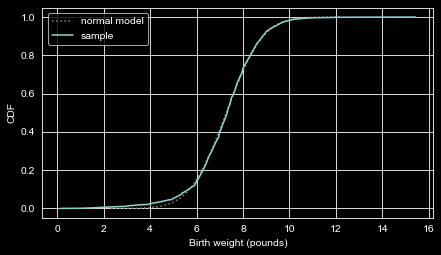

In [11]:
from empiricaldist import Cdf

cdf_birth_weight = Cdf.from_seq(birth_weights, name="sample")
two_cdf_plots(cdf_model, cdf_birth_weight, xlabel="Birth weight (pounds)")

## 6.2. Probability Density

In [1]:
def normal_pdf(xs, mu, sigma):
    """Evaluates the normal probability density function."""
    z = (xs - mu) / sigma
    return np.exp(-(z**2) / 2) / sigma / np.sqrt(2 * np.pi)

In [12]:
m, s = np.mean(trimmed), np.std(trimmed)

In [13]:
low = m - 4 * s
high = m + 4 * s
qs = np.linspace(low, high, 201)
ps = normal_pdf(qs, m, s)

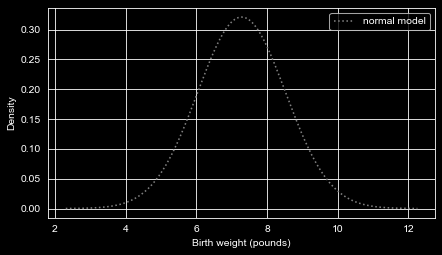

In [16]:
plt.plot(qs, ps, label="normal model", ls=":", color="gray")
decorate(xlabel="Birth weight (pounds)", ylabel="Density")

In [17]:
normal_pdf(m, m, s)

np.float64(0.32093416297880123)

We can use the probability densities to compute the probability that an outcome falls in an interval between two values, by computing the area under the curve.

In [18]:
from thinkstats import NormalPdf

pdf_model = NormalPdf(m, s, name="normal model")
pdf_model

NormalPdf(7.280883100022579, 1.2430657948614345, name='normal model')

In [19]:
pdf_model(m)

np.float64(0.32093416297880123)

In [20]:
from scipy.integrate import simpson


def area_under(pdf, low, high):
    qs = np.linspace(low, high, 501)
    ps = pdf(qs)
    return simpson(y=ps, x=qs)